# Pennycress water use: step-by-step analysis

Each step follows the same pattern: **question → why → code + plot → what we found → next question.**

Put the three CSVs (`plant-weights.csv`, `rgb2-design.csv`, `rgb2-features.csv`) in the same folder as this notebook, or change `DATA_DIR` below.

Libraries: `pandas`, `numpy`, `matplotlib`, `scipy`, `statsmodels` (`pip install pandas numpy matplotlib scipy statsmodels`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

DATA_DIR = "."   # folder with the three CSVs

# BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"
# plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False,
#                      "axes.spines.right": False, "axes.grid": True,
#                      "grid.alpha": 0.25, "lines.linewidth": 2})

weights  = pd.read_csv(f"{DATA_DIR}/plant-weights.csv", )
design   = pd.read_csv(f"{DATA_DIR}/rgb2-design.csv", )
features = pd.read_csv(f"{DATA_DIR}/rgb2-features.csv",
                       usecols=["plant_id", "datetime", "area_mm2"])

weights["dt"]  = pd.to_datetime(weights["datetime"], format="%m/%d/%Y %H:%M")
features["dt"] = pd.to_datetime(features["datetime"])
weights = weights.sort_values(["plant_id", "dt"])

# one row per plant: genotype and zinc treatment
plants = design.groupby("plant_id")[["genotype", "treatment"]].first()
print(weights.shape, design.shape, features.shape, "plants:", len(plants))

FileNotFoundError: [Errno 2] No such file or directory: './plant-weights.csv'

In [ ]:
print(weights.columns.tolist())
weights[["plant_id", "dt", "weight_g", "weight_after_watering_g"]].head(10)

In [ ]:
# Follow one pot over the whole experiment
one = weights[weights["plant_id"] == 28773]
plt.plot(one["dt"], one["weight_g"], color=BLUE, marker="o", ms=3, label="before watering")
plt.plot(one["dt"], one["weight_after_watering_g"], color=ORANGE, marker="o", ms=3, label="after watering")
plt.ylabel("pot weight (g)");
plt.title("One pot over time (plant 28773)");
plt.legend()
plt.show()

The pot is mostly soil + water, and the plant weighs almost nothing,
so weight changes are essentially water going in or out.


## Step 2: How complete is the data, and how were plants watered?
**Why:** if the after-watering column is mostly empty or watering is random, we cannot measure water use.

In [ ]:
filled = weights["weight_after_watering_g"].notna().mean()
print(f"after-watering column filled: {filled:.0%}")
print("weigh-ins per plant:", weights.groupby("plant_id").size().median())
print("date range:", weights["dt"].min(), "to", weights["dt"].max())

weights["added"] = weights["weight_after_watering_g"] - weights["weight_g"]
weights["day"] = weights["dt"].dt.normalize()
daily = weights.groupby("day").agg(
    share_watered=("added", lambda s: (s > 1).mean()),
    median_weight=("weight_g", "median"))

after-watering column filled: 80%
weigh-ins per plant: 72.0
date range: 2026-04-06 18:18:00 to 2026-05-07 11:07:00


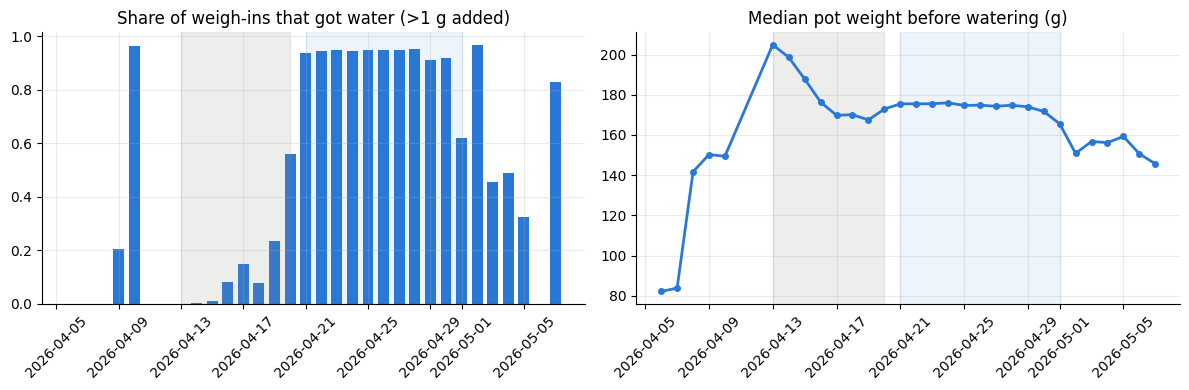

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(daily.index, daily["share_watered"], color=BLUE, width=0.7)
ax[0].set_title("Share of weigh-ins that got water (>1 g added)")
ax[0].tick_params(axis="x", rotation=45)

ax[1].plot(daily.index, daily["median_weight"], color=BLUE, marker="o", ms=4)
ax[1].set_title("Median pot weight before watering (g)")
ax[1].tick_params(axis="x", rotation=45)
for a in ax:  # shade the three phases
    a.axvspan(pd.Timestamp("2026-04-13"), pd.Timestamp("2026-04-20"), color=GRAY, alpha=0.15)
    a.axvspan(pd.Timestamp("2026-04-21"), pd.Timestamp("2026-04-30 23:59"), color=BLUE, alpha=0.08)
plt.tight_layout(); plt.show()

count    360.0
mean     180.2
std       12.1
min      127.3
25%      172.2
50%      179.9
75%      187.6
max      211.0
Name: weight_after_watering_g, dtype: float64


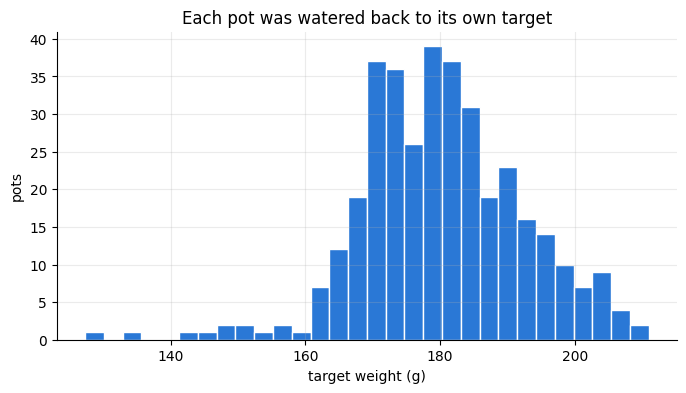

In [ ]:
steady = weights[(weights["dt"] >= "2026-04-21") & (weights["dt"] < "2026-05-01")]
target = steady.groupby("plant_id")["weight_after_watering_g"].median()
print(target.describe().round(1))
plt.hist(target.dropna(), bins=30, color=BLUE, edgecolor="white")
plt.xlabel("target weight (g)"); plt.ylabel("pots"); plt.title("Each pot was watered back to its own target")
plt.show()

**Found:** the after-watering column is ~80% filled. Pots were watered back to their **own target weight**
(median ~180 g, range 127–211 g), not given a fixed volume. Three phases:
Apr 13–20 almost no watering (grey), **Apr 21–30 watered to target 3–4×/day (blue)**, May 1+ irregular.

## Step 3: Measuring water loss
**Why:** each interval starts at a known weight (the after-watering weight), so the drop until the next weigh-in is water lost.

`loss = previous after-watering weight − next weight`, `rate = loss / hours`

9642 intervals


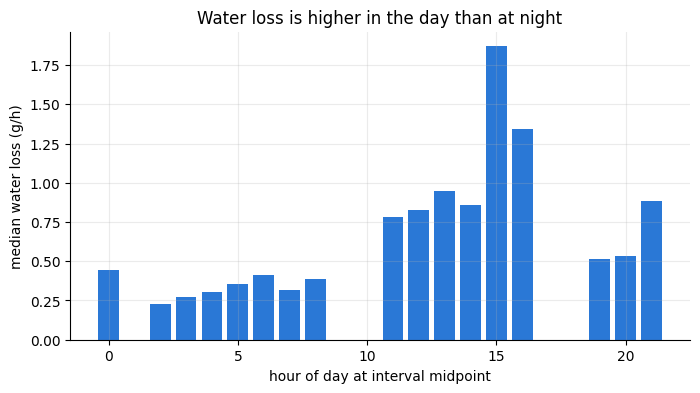

In [ ]:
g = weights.groupby("plant_id")
weights["prev_after"] = g["weight_after_watering_g"].shift()
weights["prev_dt"] = g["dt"].shift()
weights["hrs"]  = (weights["dt"] - weights["prev_dt"]).dt.total_seconds() / 3600
weights["loss"] = weights["prev_after"] - weights["weight_g"]
weights["rate"] = weights["loss"] / weights["hrs"]

iv = weights[(weights["dt"] >= "2026-04-21") & (weights["dt"] < "2026-05-01")
             & (weights["prev_dt"] >= "2026-04-20 17:00")
             & weights["loss"].notna() & weights["hrs"].between(2, 20)].copy()
iv = iv.join(plants, on="plant_id")
print(len(iv), "intervals")

# day vs night: label each interval by the clock hour at its midpoint
iv["mid_hour"] = (iv["prev_dt"] + (iv["dt"] - iv["prev_dt"]) / 2).dt.hour
by_hour = iv.groupby("mid_hour")["rate"].median()
plt.bar(by_hour.index, by_hour.values, color=BLUE)
plt.xlabel("hour of day at interval midpoint"); plt.ylabel("median water loss (g/h)")
plt.title("Water loss is higher in the day than at night")
plt.show()

**Found:** a clear daily cycle, with higher loss in the day than at night, which is consistent with plants driving it.

**Next question:** part of that loss is soil evaporation, not the plant. How do we separate them?

## Step 4: Finding soil-only (empty) pots
**Why:** a pot with no plant only loses water by soil evaporation, which gives us a baseline to subtract.
We use the image leaf area to find pots where a plant never grew.

status
grown      255
empty       62
stunted     43
Name: count, dtype: int64
status     empty  stunted  grown
treatment                       
0              8        6     46
50             5        6     49
100            8        3     49
200            2        3     55
500           18       12     30
1000          21       13     26


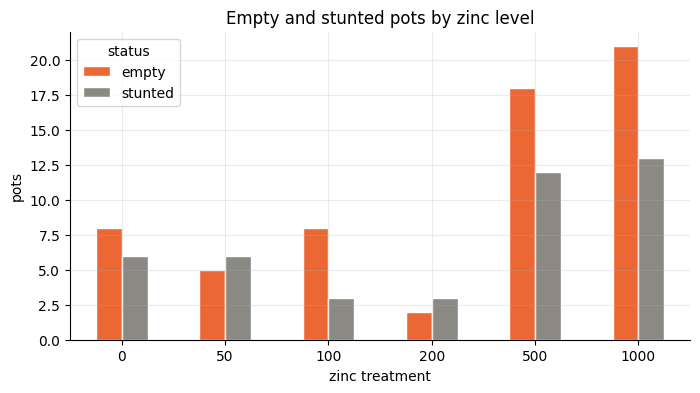

In [ ]:
plants["max_area"] = features.groupby("plant_id")["area_mm2"].max()
plants["status"] = np.where(plants["max_area"].isna() | (plants["max_area"] < 1), "empty",
                   np.where(plants["max_area"] < 10, "stunted", "grown"))
print(plants["status"].value_counts())

counts = pd.crosstab(plants["treatment"], plants["status"])[["empty", "stunted", "grown"]]
print(counts)
counts[["empty", "stunted"]].plot(kind="bar", color=[ORANGE, GRAY], edgecolor="white")
plt.xlabel("zinc treatment"); plt.ylabel("pots"); plt.title("Empty and stunted pots by zinc level")
plt.xticks(rotation=0); plt.show()

**Found:** 62 empty, 43 stunted, 255 grown pots. But **39 of the 62 empty pots are at zinc 500 or 1000.**

**Next question:** if zinc changes how fast soil dries, a mostly-high-zinc baseline would be biased. Does it?

## Step 5: Does zinc change soil evaporation?
**Why:** to make sure empty pots are a fair baseline.

In [ ]:
iv["status"] = iv["plant_id"].map(plants["status"])
iv = iv[iv["rate"].between(-0.5, 5)]           # drop scale glitches
iv["day"] = iv["dt"].dt.normalize()

# one rate per pot per day
pday = (iv.groupby(["plant_id", "day"])
          .agg(loss=("loss", "sum"), hrs=("hrs", "sum")).reset_index())
pday["rate"] = pday["loss"] / pday["hrs"]
pday = pday.join(plants, on="plant_id")

empty = pday[pday["status"] == "empty"]
print(empty.groupby(empty["treatment"] >= 500)["rate"].median().rename({False: "zinc 0-200", True: "zinc 500-1000"}))

zn_levels = sorted(empty["treatment"].unique())
plt.boxplot([empty.loc[empty["treatment"] == z, "rate"] for z in zn_levels],
            tick_labels=zn_levels, showfliers=False)
plt.xlabel("zinc treatment"); plt.ylabel("water loss (g/h)")
plt.title("Empty pots dry at the same rate at every zinc level")
plt.show()

NameError: name 'iv' is not defined

**Found:** 0.42 g/h (low zinc) vs 0.43 g/h (high zinc). There's no difference, so the baseline is safe.

**Next question:** do empty pots represent the soil in *planted* pots? Cross-check with the early days.

## Step 6: Checking the baseline two ways
**Why:** in the first days seedlings are tiny, so planted pots should lose water about as fast as empty pots.
If both methods agree, the baseline is trustworthy. We also check whether a pot's target weight matters.

status      empty  grown
day                     
2026-04-21  0.534  0.555
2026-04-22  0.520  0.567
2026-04-23  0.500  0.567
2026-04-24  0.443  0.534
2026-04-25  0.273  0.409
2026-04-26  0.408  0.656
2026-04-27  0.430  0.784
2026-04-28  0.317  0.742
2026-04-29  0.332  0.893
2026-04-30  0.318  0.909


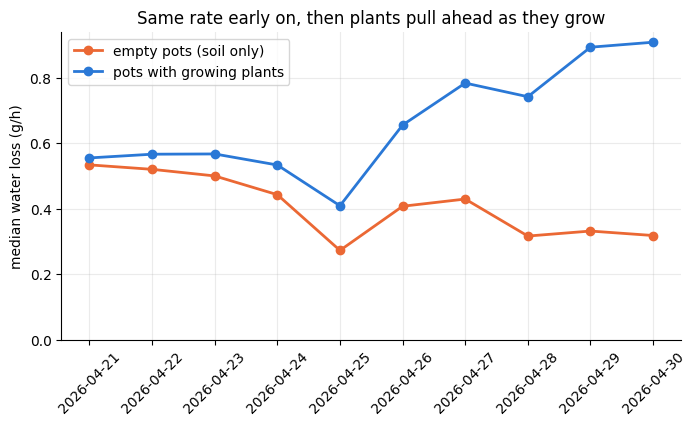

In [ ]:
trend = pday[pday["status"] != "stunted"].groupby(["day", "status"])["rate"].median().unstack()
print(trend.round(3))
plt.plot(trend.index, trend["empty"], color=ORANGE, marker="o", label="empty pots (soil only)")
plt.plot(trend.index, trend["grown"], color=BLUE, marker="o", label="pots with growing plants")
plt.ylabel("median water loss (g/h)"); plt.ylim(0, None); plt.legend()
plt.title("Same rate early on, then plants pull ahead as they grow")
plt.xticks(rotation=45); plt.show()

In [ ]:
# Does target weight change soil evaporation? (controlling for day)
empty = empty.join(target.rename("target"), on="plant_id")
m = smf.ols("rate ~ C(day) + target", data=empty).fit()
print(f"target-weight effect: {m.params['target']:.5f} g/h per g, p = {m.pvalues['target']:.2f}")

target-weight effect: 0.00004 g/h per g, p = 0.95


**Found:** Apr 21–23 planted ≈ empty (0.56 vs 0.52 g/h); by Apr 30 it's 0.91 vs 0.32 g/h. The two methods agree.
Target weight has no effect (p ≈ 0.95). Empty-pot evaporation drifts over time, so we use **a separate baseline for each day**.

`plant water use (T) = pot water loss − that day's median empty-pot loss`

**Next question:** what drives how much water a plant uses?

## Step 7: Plant water use vs leaf area
**Why:** bigger plants have more leaf surface, and zinc shrinks plants. We must separate size from efficiency.

Spearman rho = 0.79, p = 0.0e+00


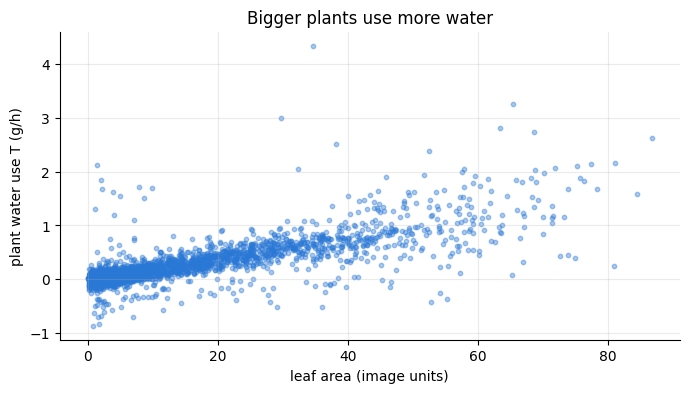

In [ ]:
baseline = pday[pday["status"] == "empty"].groupby("day")["rate"].median().rename("soil")
pday = pday.join(baseline, on="day")
pday["T"] = pday["rate"] - pday["soil"]

# leaf area for each pot-day (median of that day's images)
features["day"] = features["dt"].dt.normalize()
area_day = features.groupby(["plant_id", "day"])["area_mm2"].median().rename("area")
pday = pday.join(area_day, on=["plant_id", "day"])

grown = pday[(pday["status"] == "grown")].dropna(subset=["area", "T"])
rho, p = stats.spearmanr(grown["area"], grown["T"])
print(f"Spearman rho = {rho:.2f}, p = {p:.1e}")

plt.scatter(grown["area"], grown["T"], s=10, alpha=0.4, color=BLUE)
plt.xlabel("leaf area (image units)"); plt.ylabel("plant water use T (g/h)")
plt.title("Bigger plants use more water")
plt.show()

**Found:** a strong link (rho ≈ 0.78). So we must compare **water use per unit leaf area**.

**Next question:** do genotypes differ in how zinc changes water use per leaf area?

## Step 8: The formal test
**Why:** the quick look wasn't a statistical test.

**Method (two-stage, simple and robust):**
1. For each plant, one number: water use per leaf area = slope of T on area through the origin,
   using days with area ≥ 5 (at least 3 days), trimming the extreme 1% at each end.
2. Two-way ANOVA: genotype × zinc on those per-plant numbers (zinc treated as a number on a log scale,
   because some genotypes have no survivors at high zinc and a zinc-as-categories model breaks on those empty groups).

In [ ]:
use = grown[grown["area"] >= 5]
per_plant = use.groupby("plant_id").apply(
    lambda s: pd.Series({"wue": (s["T"] * s["area"]).sum() / (s["area"] ** 2).sum(),
                         "ndays": len(s)}))
per_plant = per_plant[per_plant["ndays"] >= 3].join(plants[["genotype", "treatment"]])
lo, hi = per_plant["wue"].quantile([0.01, 0.99])
per_plant = per_plant[per_plant["wue"].between(lo, hi)]
print(len(per_plant), "plants")

# zinc as a number on a log scale (0 -> 0, 1000 -> ~2); avoids empty genotype x zinc groups
per_plant["zn"] = np.log10(per_plant["treatment"] + 10) - 1
model = smf.ols("wue ~ C(genotype) * zn", data=per_plant).fit()
print(sm.stats.anova_lm(model, typ=2).round(4))

# robustness check: same test on ranks
per_plant["wue_rank"] = per_plant["wue"].rank()
print(sm.stats.anova_lm(smf.ols("wue_rank ~ C(genotype) * zn", data=per_plant).fit(), typ=2).round(4))

223 plants


                sum_sq     df       F  PR(>F)
C(genotype)     0.0008   11.0  1.8742  0.0446
zn              0.0000    1.0  0.1579  0.6915
C(genotype):zn  0.0004   11.0  0.8736  0.5672
Residual        0.0074  199.0     NaN     NaN
                     sum_sq     df       F  PR(>F)
C(genotype)      74234.1981   11.0  1.6607  0.0847
zn                 364.0547    1.0  0.0896  0.7650
C(genotype):zn   40604.1575   11.0  0.9084  0.5333
Residual        808678.5340  199.0     NaN     NaN


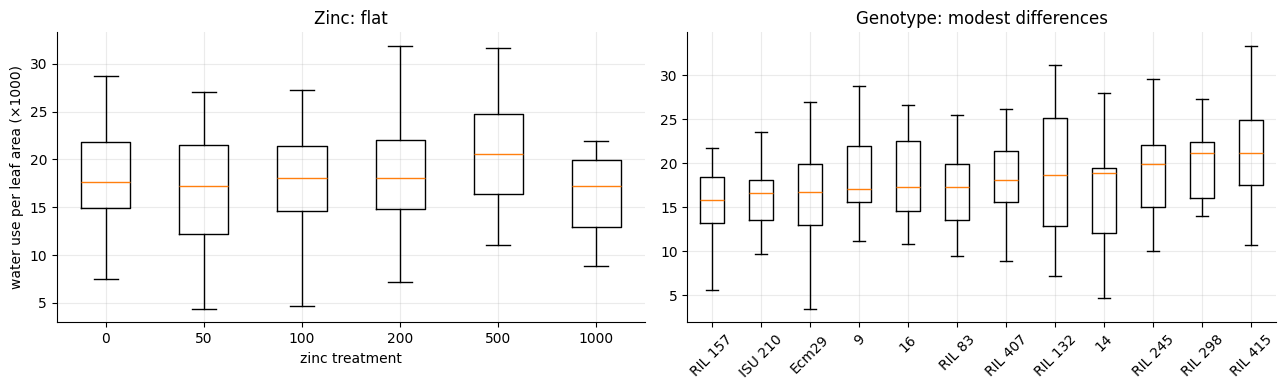

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

zs = sorted(per_plant["treatment"].unique())
ax[0].boxplot([per_plant.loc[per_plant["treatment"] == z, "wue"] * 1000 for z in zs],
              tick_labels=zs, showfliers=False)
ax[0].set_xlabel("zinc treatment"); ax[0].set_ylabel("water use per leaf area (×1000)")
ax[0].set_title("Zinc: flat")

order = per_plant.groupby("genotype")["wue"].median().sort_values().index
ax[1].boxplot([per_plant.loc[per_plant["genotype"] == gname, "wue"] * 1000 for gname in order],
              tick_labels=order, showfliers=False)
ax[1].set_title("Genotype: modest differences"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

treatment
0       41.5
50      48.6
100     43.3
200     37.9
500     34.6
1000    22.1
Name: area, dtype: float64


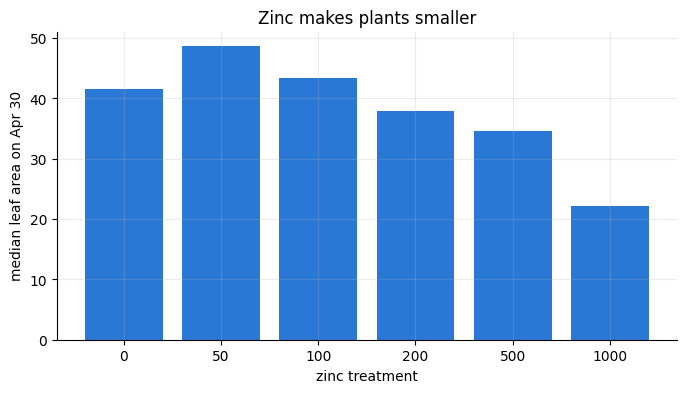

treatment  0     50    100   200   500   1000
genotype                                     
14            2     3     3     2     1     0
16            2     2     2     3     1     1
9             3     4     5     4     1     3
Ecm29         5     5     5     4     4     0
ISU 210       3     5     5     5     2     2
RIL 132       3     3     4     4     2     0
RIL 157       4     3     5     4     1     1
RIL 245       5     5     4     5     5     3
RIL 298       3     5     5     4     0     0
RIL 407       5     5     4     5     5     4
RIL 415       5     4     3     5     3     2
RIL 83        2     1     1     3     0     1


In [ ]:
# Zinc still shrinks the plant: leaf area on the last day of the window
last = grown[grown["day"] == grown["day"].max()]
area_by_zn = last.groupby("treatment")["area"].median()
print(area_by_zn.round(1))
plt.bar(area_by_zn.index.astype(str), area_by_zn.values, color=BLUE)
plt.xlabel("zinc treatment"); plt.ylabel("median leaf area on Apr 30")
plt.title("Zinc makes plants smaller")
plt.show()

# how thin are the high-zinc groups?
print(pd.crosstab(per_plant["genotype"], per_plant["treatment"]))

**Found:**

| Effect on water use per leaf area | p (ANOVA) | p (rank check) | Verdict |
|---|---|---|---|
| Genotype × zinc | ~0.57 | ~0.53 | no evidence |
| Zinc | ~0.69 | ~0.77 | no effect |
| Genotype | ~0.045 | ~0.085 | weak / borderline |

1. **Zinc lowers water use by shrinking plants** (leaf area ~41 → ~22 from zinc 0 to 1000), not by changing per-leaf use. This is the solid result.
2. **Genotype may set per-leaf water use** (RIL 157 lowest, RIL 415 highest), but the evidence is borderline. It was stronger (p ≈ 0.02)
   when leaf area was matched to each weigh-in by nearest image time instead of the daily median, so treat it as a lead, not a finding.
3. **Caveat:** many genotype × high-zinc groups have 0–2 surviving plants, so a moderate interaction can't be detected here, and survivors are likely the toughest plants.

**Next question:** would per-leaf differences show up under water stress? The May 1–7 period (irregular watering, falling weights)
may be a drought phase. Confirm with ORNL before analysing it.